# Understanding Execution Algorithms (VWAP & TWAP)


### What is VWAP (Volume-Weighted Average Price)?

VWAP is a benchmark price used by traders to execute large orders efficiently. It calculates the average price of a security, weighted by trade volume, ensuring the execution is close to the day’s typical price.

Why is VWAP important?

✅ Minimizes market impact – avoids pushing the price too high/low.

✅ Used by institutional traders – ensures fair execution prices.

✅ Acts as a trading signal – price above VWAP = bullish, below VWAP = bearish.

In [2]:
import numpy as np

def calculate_vwap(prices, volumes):
    """Calculate Volume-Weighted Average Price (VWAP)"""
    return np.sum(prices * volumes) / np.sum(volumes)

# Example data
prices = np.array([100, 102, 101, 103, 104])
volumes = np.array([200, 180, 220, 210, 190])

# Compute VWAP
vwap = calculate_vwap(prices, volumes)
print(f"VWAP: {vwap:.2f}")


VWAP: 101.97


## What is TWAP?

TWAP is another execution algorithm that distributes an order evenly over time. Instead of weighting by volume, TWAP gives equal importance to every time period.

### Why is TWAP important?

✅ Used when volume is low – prevents price manipulation.

✅ Helps traders avoid large price swings by spreading execution.

✅ Less complex than VWAP – equal weighting for each time period.

In [3]:
def calculate_twap(prices):
    """Calculate Time-Weighted Average Price (TWAP)"""
    return np.mean(prices)

# Example data
prices = np.array([100, 102, 101, 103, 104])

# Compute TWAP
twap = calculate_twap(prices)
print(f"TWAP: {twap:.2f}")


TWAP: 102.00


## simulate VWAP & TWAP on real/historical market data

[*********************100%***********************]  1 of 1 completed

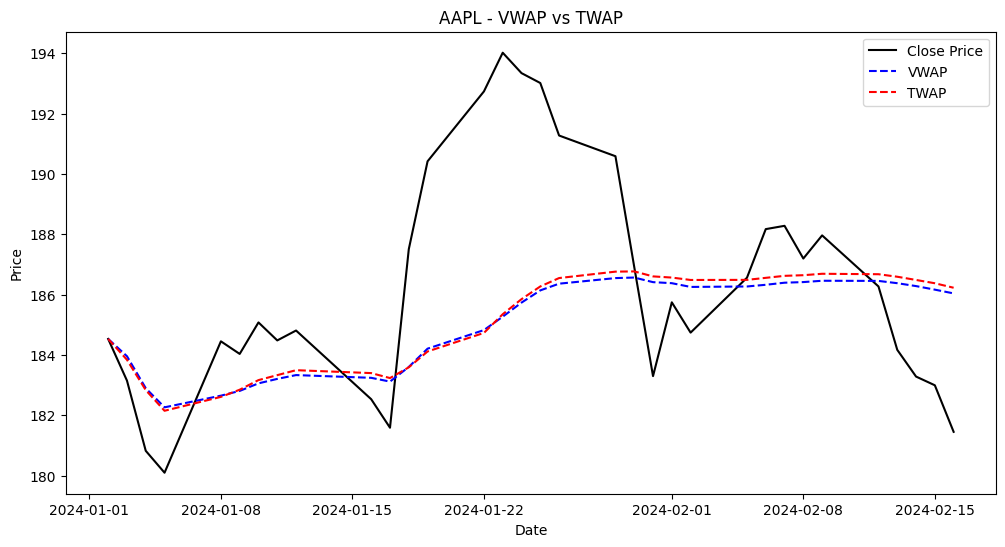

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fetch historical data from Yahoo Finance
def fetch_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date, interval="1d")
    return stock_data[['Close', 'Volume']]

# Calculate VWAP
def calculate_vwap(data):
    typical_price = (data['Close'])  # Simplified, can use (High + Low + Close) / 3
    vwap = (typical_price * data['Volume']).cumsum() / data['Volume'].cumsum()
    data['VWAP'] = vwap
    return data

# Calculate TWAP
def calculate_twap(data):
    data['TWAP'] = data['Close'].expanding().mean()
    return data

# Plot VWAP & TWAP
def plot_vwap_twap(data, ticker):
    plt.figure(figsize=(12,6))
    plt.plot(data.index, data['Close'], label="Close Price", color='black')
    plt.plot(data.index, data['VWAP'], label="VWAP", linestyle='dashed', color='blue')
    plt.plot(data.index, data['TWAP'], label="TWAP", linestyle='dashed', color='red')
    
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title(f"{ticker} - VWAP vs TWAP")
    plt.legend()
    plt.show()

# Run Simulation
ticker = "AAPL"  # Change to any stock symbol
start_date = "2024-01-01"
end_date = "2024-02-20"

data = fetch_stock_data(ticker, start_date, end_date)
data = calculate_vwap(data)
data = calculate_twap(data)

plot_vwap_twap(data, ticker)
